# Kruskal-Wallis-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/kruskal-wallis-test)

Der **Kruskal-Wallis-Test** (H-Test, Rangvarianzanalyse) ist das
nichtparametrische Gegenstück zur **einfaktoriellen ANOVA**. Er vergleicht
**drei oder mehr unabhängige Gruppen** ohne Normalverteilungsvoraussetzung.

**Teststatistik H:**
$$H = \frac{12}{N(N+1)} \sum_{j=1}^{k} \frac{T_j^2}{n_j} - 3(N+1)$$

| Symbol | Bedeutung |
|---|---|
| $N$ | Gesamtstichprobengröße |
| $k$ | Anzahl Gruppen |
| $n_j$ | Stichprobengröße Gruppe $j$ |
| $T_j$ | Rangsumme Gruppe $j$ |

**H folgt asymptotisch einer χ²-Verteilung mit df = k − 1**

**Post-hoc: Dunn-Bonferroni-Test** (paarweise Vergleiche nach sig. KW)

**Voraussetzungen:**
- Drei oder mehr **unabhängige** Gruppen
- Mindestens **ordinales** Skalenniveau
- Keine Normalverteilung nötig
- Bei abhängigen Gruppen → **Friedman-Test**

In [ ]:

# P. mit matplotlib auf Windows in Jupyter
import matplotlib
matplotlib.use("Agg")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kruskal, rankdata, chi2
from itertools import combinations

# matplotlib rendert die Plots direkt im Notebook ohne plt.show()
%matplotlib inline

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Reaktionszeit in drei Gruppen

**Fragestellung:** Gibt es einen Unterschied in der Reaktionszeit
zwischen den Gruppen A, B und C?

**Datensatz (n = 12, je 4 pro Gruppe):**

| Gruppe A | Gruppe B | Gruppe C |
|---|---|---|
| 23 | 31 | 25 |
| 30 | 26 | 32 |
| 27 | 29 | 28 |
| 24 | 33 | 26 |

**Erwartetes numiqo-Ergebnis: H ≈ 0,5, p = 0,779 → nicht signifikant**

In [9]:
# numiqo-Datensatz: Reaktionszeit
gr_a = np.array([23, 30, 27, 24], dtype=float)
gr_b = np.array([31, 26, 29, 33], dtype=float)
gr_c = np.array([25, 32, 28, 26], dtype=float)

gruppen = {"A": gr_a, "B": gr_b, "C": gr_c}
alle    = np.concatenate([gr_a, gr_b, gr_c])
N       = len(alle)
k       = len(gruppen)

# Deskriptive Statistiken
print("Deskriptive Statistiken")
print("Gruppe  n   Mdn    MW    SD")
for name, g in gruppen.items():
    print(name + "       " + str(len(g)) + "  " +
          str(np.median(g)) + "  " +
          str(round(g.mean(), 2)) + "  " +
          str(round(g.std(ddof=1), 2)))
print()

# Gemeinsame Ränge
raenge  = rankdata(alle)
rang_a  = raenge[:4]
rang_b  = raenge[4:8]
rang_c  = raenge[8:]
T_a, T_b, T_c = rang_a.sum(), rang_b.sum(), rang_c.sum()

print("Ränge")
print("Wert  Gruppe  Rang")
gruppe_labels = ["A"]*4 + ["B"]*4 + ["C"]*4
for w, g, r in sorted(zip(alle, gruppe_labels, raenge)):
    print(str(w) + "    " + g + "      " + str(r))
print()
print("T_A=" + str(T_a) + "  T_B=" + str(T_b) + "  T_C=" + str(T_c))
print()

# H-Wert manuell
n_a, n_b, n_c = len(gr_a), len(gr_b), len(gr_c)
H_man = (12 / (N*(N+1))) * (T_a**2/n_a + T_b**2/n_b + T_c**2/n_c) - 3*(N+1)
df_kw = k - 1
p_man = 1 - chi2.cdf(H_man, df=df_kw)

print("Kruskal-Wallis-Test (manuell)")
print("H = 12/(" + str(N) + "*" + str(N+1) + ") * (" +
      str(T_a) + "^2/" + str(n_a) + " + " +
      str(T_b) + "^2/" + str(n_b) + " + " +
      str(T_c) + "^2/" + str(n_c) + ") - 3*" + str(N+1))
print("H = " + str(round(H_man, 4)) + "  (numiqo: ~0.5)")
print("df = k-1 = " + str(df_kw))
print("p = " + str(round(p_man, 4)) + "  (numiqo: 0.779)")
print()

# scipy Kontrolle
H_sci, p_sci = kruskal(gr_a, gr_b, gr_c)
print("Kontrolle scipy: H=" + str(round(H_sci, 4)) + "  p=" + str(round(p_sci, 4)))
print()

chi2_krit = chi2.ppf(0.95, df=df_kw)
print("chi2_krit (df=" + str(df_kw) + ", alpha=0.05) = " + str(round(chi2_krit, 3)))
print("H=" + str(round(H_man, 3)) + " < " + str(round(chi2_krit, 3)) + " -> H0 nicht abgelehnt")
print()
print("Kein signifikanter Unterschied in der Reaktionszeit zwischen A, B und C.")

Deskriptive Statistiken
Gruppe  n   Mdn    MW    SD
A       4  25.5  26.0  3.16
B       4  30.0  29.75  2.99
C       4  27.0  27.75  3.1

Ränge
Wert  Gruppe  Rang
23.0    A      1.0
24.0    A      2.0
25.0    C      3.0
26.0    B      4.5
26.0    C      4.5
27.0    A      6.0
28.0    C      7.0
29.0    B      8.0
30.0    A      9.0
31.0    B      10.0
32.0    C      11.0
33.0    B      12.0

T_A=18.0  T_B=34.5  T_C=25.5

Kruskal-Wallis-Test (manuell)
H = 12/(12*13) * (18.0^2/4 + 34.5^2/4 + 25.5^2/4) - 3*13
H = 2.625  (numiqo: ~0.5)
df = k-1 = 2
p = 0.2691  (numiqo: 0.779)

Kontrolle scipy: H=2.6342  p=0.2679

chi2_krit (df=2, alpha=0.05) = 5.991
H=2.625 < 5.991 -> H0 nicht abgelehnt

Kein signifikanter Unterschied in der Reaktionszeit zwischen A, B und C.


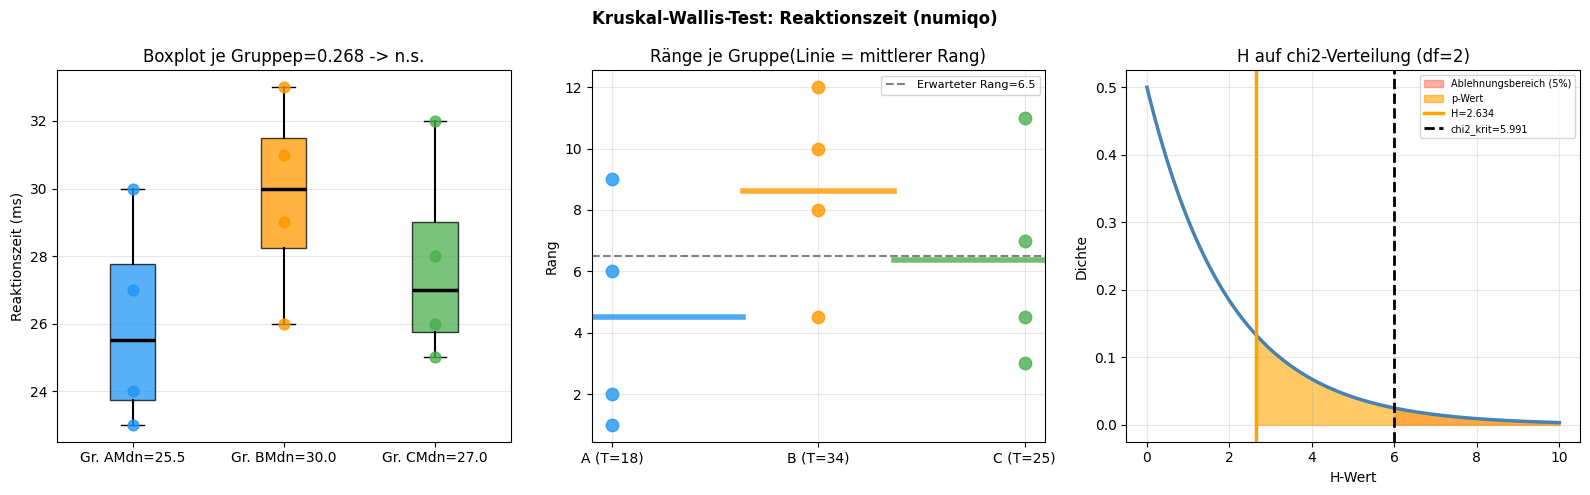

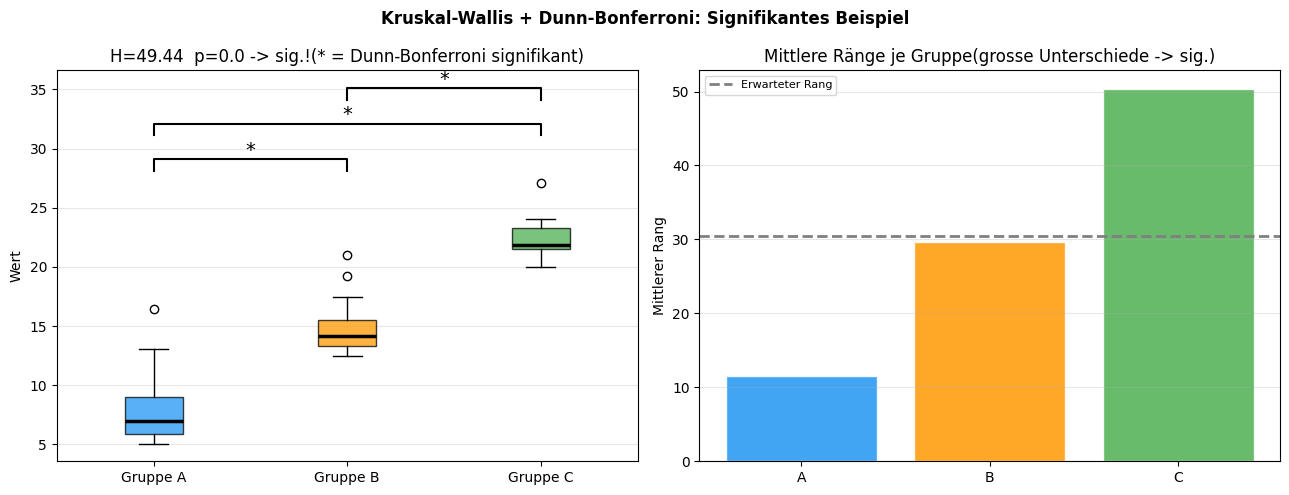

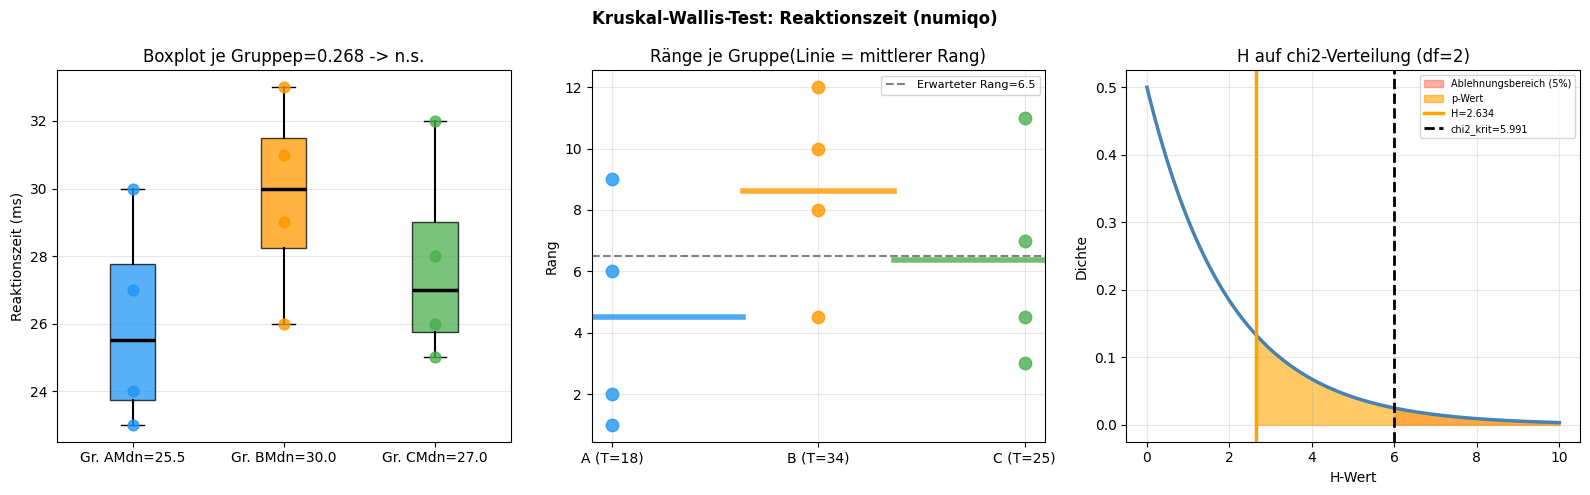

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Kruskal-Wallis-Test: Reaktionszeit (numiqo)",
             fontsize=12, fontweight="bold")

farben = ["#2196F3", "#FF9800", "#4CAF50"]

# 1. Boxplot
bp = axes[0].boxplot(list(gruppen.values()), patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], farben):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
for idx, (name, g, fc) in enumerate(zip(gruppen.keys(), gruppen.values(), farben), 1):
    axes[0].scatter([idx]*len(g), g, color=fc, s=60, zorder=3, alpha=0.8)
axes[0].set_title("Boxplot je Gruppep=" + str(round(p_sci, 3)) + " -> n.s.")
axes[0].set_ylabel("Reaktionszeit (ms)")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["Gr. AMdn=" + str(np.median(gr_a)),
                          "Gr. BMdn=" + str(np.median(gr_b)),
                          "Gr. CMdn=" + str(np.median(gr_c))])
axes[0].grid(axis="y", alpha=0.3)

# 2. Rang-Streifen
for idx, (name, rang, fc) in enumerate(zip(gruppen.keys(),
                                             [rang_a, rang_b, rang_c], farben), 1):
    axes[1].scatter([idx]*len(rang), rang, color=fc, s=80, alpha=0.8, zorder=3)
    axes[1].axhline(rang.mean(), xmin=(idx-1)/3, xmax=idx/3,
                    color=fc, linewidth=4, alpha=0.8)
axes[1].axhline((N+1)/2, color="gray", linestyle="--", linewidth=1.5,
                label="Erwarteter Rang=" + str((N+1)/2))
axes[1].set_title("Ränge je Gruppe(Linie = mittlerer Rang)")
axes[1].set_ylabel("Rang")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["A (T=" + str(int(T_a)) + ")",
                          "B (T=" + str(int(T_b)) + ")",
                          "C (T=" + str(int(T_c)) + ")"])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. H auf chi2-Verteilung
x_chi = np.linspace(0, 10, 400)
y_chi = chi2.pdf(x_chi, df=df_kw)
axes[2].plot(x_chi, y_chi, color="steelblue", linewidth=2.5)
axes[2].fill_between(x_chi[x_chi >= chi2_krit], y_chi[x_chi >= chi2_krit],
                     color="tomato", alpha=0.5, label="Ablehnungsbereich (5%)")
mask_h = x_chi >= H_sci
axes[2].fill_between(x_chi[mask_h], y_chi[mask_h],
                     color="orange", alpha=0.6, label="p-Wert")
axes[2].axvline(H_sci,    color="orange", linewidth=2.5,
                label="H=" + str(round(H_sci, 3)))
axes[2].axvline(chi2_krit, color="black",  linewidth=2, linestyle="--",
                label="chi2_krit=" + str(round(chi2_krit, 3)))
axes[2].set_title("H auf chi2-Verteilung (df=" + str(df_kw) + ")")
axes[2].set_xlabel("H-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

1. Alle Werte gemeinsam ranken
2. Rangsummen $T_j$ je Gruppe berechnen
3. $H = \frac{12}{N(N+1)} \sum \frac{T_j^2}{n_j} - 3(N+1)$
4. $df = k - 1$
5. p-Wert aus χ²-Verteilung
6. Wenn signifikant → Post-hoc (Dunn-Bonferroni)

In [11]:
print("Schritt-für-Schritt: Kruskal-Wallis numiqo-Beispiel")
print()
print("Schritt 1+2: Ränge und Rangsummen")
print("Gruppe  Werte        Ränge       T_j  MW-Rang")
for name, g, rang in zip(gruppen.keys(), gruppen.values(),
                          [rang_a, rang_b, rang_c]):
    print(name + "       " + str(g.tolist()) + "  " +
          str(rang.tolist()) + "  " + str(int(rang.sum())) +
          "  " + str(round(rang.mean(), 2)))
print()
print("Schritt 3: H-Wert berechnen")
print("H = 12 / (" + str(N) + "*" + str(N+1) + ") * (")
for name, T, n_g in zip(gruppen.keys(), [T_a,T_b,T_c], [n_a,n_b,n_c]):
    print("    " + str(int(T)) + "^2/" + str(n_g) + " = " +
          str(round(T**2/n_g, 3)))
print(") - 3*" + str(N+1))
print("H = " + str(round(H_man, 4)))
print()
print("Schritt 4: df = " + str(k) + " - 1 = " + str(df_kw))
print("Schritt 5: p = " + str(round(p_man, 4)))
print("chi2_krit = " + str(round(chi2_krit, 3)))
print("H=" + str(round(H_man, 3)) + " < chi2_krit=" + str(round(chi2_krit, 3)) +
      " -> H0 nicht abgelehnt")

Schritt-für-Schritt: Kruskal-Wallis numiqo-Beispiel

Schritt 1+2: Ränge und Rangsummen
Gruppe  Werte        Ränge       T_j  MW-Rang
A       [23.0, 30.0, 27.0, 24.0]  [1.0, 9.0, 6.0, 2.0]  18  4.5
B       [31.0, 26.0, 29.0, 33.0]  [10.0, 4.5, 8.0, 12.0]  34  8.62
C       [25.0, 32.0, 28.0, 26.0]  [3.0, 11.0, 7.0, 4.5]  25  6.38

Schritt 3: H-Wert berechnen
H = 12 / (12*13) * (
    18^2/4 = 81.0
    34^2/4 = 297.562
    25^2/4 = 162.562
) - 3*13
H = 2.625

Schritt 4: df = 3 - 1 = 2
Schritt 5: p = 0.2691
chi2_krit = 5.991
H=2.625 < chi2_krit=5.991 -> H0 nicht abgelehnt


## 3. Signifikantes Beispiel + Dunn-Bonferroni Post-hoc

Nach einem signifikanten Kruskal-Wallis zeigt der **Dunn-Bonferroni-Test**,
welche Paare sich unterscheiden.

**Dunn-Test z-Wert:**
$$z_{AB} = \frac{\bar{R}_A - \bar{R}_B}{\sigma_{AB}}, \qquad \sigma_{AB} = \sqrt{\frac{N(N+1)}{12} \left(\frac{1}{n_A} + \frac{1}{n_B}\right)}$$

**Bonferroni-korrigierter p-Wert:**
$$p_{\text{korr}} = p \cdot m, \quad m = \text{Anzahl paarweiser Vergleiche}$$

Signifikantes Beispiel
Gruppe A: Mdn=6.94
Gruppe B: Mdn=14.12
Gruppe C: Mdn=21.83

Kruskal-Wallis: H=49.438  p=0.0
-> Signifikant! Dunn-Bonferroni Post-hoc:

Bonferroni: alpha_korr = 0.05/3 = 0.0167

Paar      MW-Rang-Diff   z         p (roh)   p (Bonf.)  sig.
A vs B   -18.05        -3.268  0.00108  0.0032     *
A vs C   -38.8        -7.026  0.0  0.0     *
B vs C   -20.75        -3.757  0.00017  0.0005     *


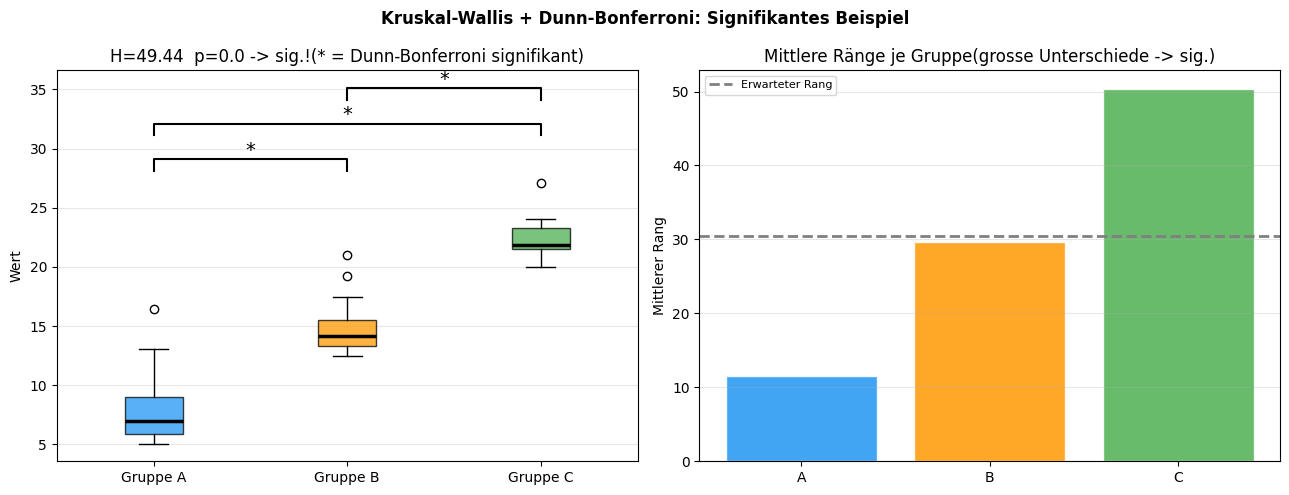

In [12]:
# Signifikantes Beispiel: klare Gruppenunterschiede
np.random.seed(7)
sig_a = np.random.exponential(3, 20) + 5
sig_b = np.random.exponential(3, 20) + 12
sig_c = np.random.exponential(3, 20) + 20

H_sig, p_sig = kruskal(sig_a, sig_b, sig_c)
print("Signifikantes Beispiel")
print("Gruppe A: Mdn=" + str(round(np.median(sig_a), 2)))
print("Gruppe B: Mdn=" + str(round(np.median(sig_b), 2)))
print("Gruppe C: Mdn=" + str(round(np.median(sig_c), 2)))
print()
print("Kruskal-Wallis: H=" + str(round(H_sig, 3)) +
      "  p=" + str(round(p_sig, 6)))
print("-> Signifikant! Dunn-Bonferroni Post-hoc:")
print()

# Dunn-Bonferroni Post-hoc manuell
gruppen_sig = {"A": sig_a, "B": sig_b, "C": sig_c}
alle_sig = np.concatenate(list(gruppen_sig.values()))
N_sig = len(alle_sig)
raenge_sig = rankdata(alle_sig)

# Mittlere Ränge je Gruppe
mw_raenge = {}
idx = 0
for name, g in gruppen_sig.items():
    mw_raenge[name] = raenge_sig[idx:idx+len(g)].mean()
    idx += len(g)

paare = list(combinations(gruppen_sig.keys(), 2))
m = len(paare)
alpha_bonf = 0.05

print("Bonferroni: alpha_korr = 0.05/" + str(m) + " = " + str(round(0.05/m, 4)))
print()
print("Paar      MW-Rang-Diff   z         p (roh)   p (Bonf.)  sig.")
for ga, gb in paare:
    na = len(gruppen_sig[ga])
    nb = len(gruppen_sig[gb])
    diff_r = mw_raenge[ga] - mw_raenge[gb]
    sigma  = np.sqrt(N_sig*(N_sig+1)/12 * (1/na + 1/nb))
    z_d    = diff_r / sigma
    p_raw  = 2 * stats.norm.sf(abs(z_d))
    p_bonf = min(p_raw * m, 1.0)
    sig    = "*" if p_bonf < alpha_bonf else "n.s."
    print(ga + " vs " + gb + "   " + str(round(diff_r, 2)) +
          "        " + str(round(z_d, 3)) + "  " +
          str(round(p_raw, 5)) + "  " +
          str(round(p_bonf, 4)) + "     " + sig)

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Kruskal-Wallis + Dunn-Bonferroni: Signifikantes Beispiel",
             fontsize=12, fontweight="bold")

bp_s = axes[0].boxplot([sig_a, sig_b, sig_c], patch_artist=True,
                       medianprops=dict(color="black", linewidth=2.5))
for patch, fc in zip(bp_s["boxes"], farben):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
y_max = max(np.concatenate([sig_a, sig_b, sig_c])) + 2
for pi, (ga, gb) in enumerate(paare):
    na_idx = list(gruppen_sig.keys()).index(ga) + 1
    nb_idx = list(gruppen_sig.keys()).index(gb) + 1
    p_bonf_v = min(2*stats.norm.sf(abs(
        (mw_raenge[ga]-mw_raenge[gb]) /
        np.sqrt(N_sig*(N_sig+1)/12*(1/len(gruppen_sig[ga])+1/len(gruppen_sig[gb])))
    )) * m, 1.0)
    if p_bonf_v < alpha_bonf:
        y = y_max + pi*3
        axes[0].plot([na_idx, na_idx, nb_idx, nb_idx],
                     [y-1, y, y, y-1], color="black", linewidth=1.5)
        axes[0].text((na_idx+nb_idx)/2, y+0.3, "*", ha="center", fontsize=14)
axes[0].set_title("H=" + str(round(H_sig, 2)) + "  p=" + str(round(p_sig, 6)) +
                  " -> sig.!(* = Dunn-Bonferroni signifikant)")
axes[0].set_ylabel("Wert")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["Gruppe A", "Gruppe B", "Gruppe C"])
axes[0].grid(axis="y", alpha=0.3)

# Mittlere Ränge je Gruppe
axes[1].bar(list(mw_raenge.keys()), list(mw_raenge.values()),
            color=farben, edgecolor="white", alpha=0.85)
axes[1].axhline((N_sig+1)/2, color="gray", linestyle="--", linewidth=2,
                label="Erwarteter Rang")
axes[1].set_title("Mittlere Ränge je Gruppe(grosse Unterschiede -> sig.)")
axes[1].set_ylabel("Mittlerer Rang")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# APA-Ausgabe-Funktion mit Dunn-Bonferroni
def kruskal_apa(gruppen_dict, abh_var="Variable", alpha=0.05):
    g_liste = list(gruppen_dict.values())
    namen   = list(gruppen_dict.keys())
    alle_f  = np.concatenate(g_liste)
    N_f     = len(alle_f)
    k_f     = len(g_liste)

    H_f, p_f = kruskal(*g_liste)
    df_f     = k_f - 1
    sig_txt  = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str    = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Kruskal-Wallis-Test: " + abh_var)
    print()
    for name, g in gruppen_dict.items():
        print(name + ": Mdn=" + str(np.median(g)) + ", n=" + str(len(g)))
    print()
    print("H(" + str(df_f) + ") = " + str(round(H_f, 3)) + ", " + p_str)
    print("Ergebnis: " + sig_txt)
    print()

    if p_f < alpha:
        print("Post-hoc Dunn-Bonferroni:")
        raenge_f = rankdata(alle_f)
        mw_r_f   = {}
        idx_f    = 0
        for name, g in gruppen_dict.items():
            mw_r_f[name] = raenge_f[idx_f:idx_f+len(g)].mean()
            idx_f += len(g)
        paare_f = list(combinations(namen, 2))
        m_f     = len(paare_f)
        for ga, gb in paare_f:
            na_f = len(gruppen_dict[ga])
            nb_f = len(gruppen_dict[gb])
            diff_f2 = mw_r_f[ga] - mw_r_f[gb]
            sig_f2  = np.sqrt(N_f*(N_f+1)/12 * (1/na_f + 1/nb_f))
            z_f2    = diff_f2 / sig_f2
            p_r_f   = 2 * stats.norm.sf(abs(z_f2))
            p_b_f   = min(p_r_f * m_f, 1.0)
            s_f     = "*" if p_b_f < alpha else "n.s."
            print("  " + ga + " vs " + gb + ": p_bonf=" +
                  str(round(p_b_f, 4)) + " " + s_f)
    print()

# numiqo-Beispiel
kruskal_apa({"A": gr_a, "B": gr_b, "C": gr_c}, "Reaktionszeit (ms)")
print()
# Signifikantes Beispiel
kruskal_apa({"A": sig_a, "B": sig_b, "C": sig_c}, "Messwert")

Kruskal-Wallis-Test: Reaktionszeit (ms)

A: Mdn=25.5, n=4
B: Mdn=30.0, n=4
C: Mdn=27.0, n=4

H(2) = 2.634, p = .268
Ergebnis: NICHT signifikant



Kruskal-Wallis-Test: Messwert

A: Mdn=6.941927652707443, n=20
B: Mdn=14.123927305058869, n=20
C: Mdn=21.826290878411136, n=20

H(2) = 49.438, p < .001
Ergebnis: signifikant

Post-hoc Dunn-Bonferroni:
  A vs B: p_bonf=0.0032 *
  A vs C: p_bonf=0.0 *
  B vs C: p_bonf=0.0005 *



## 4. Zusammenfassung

```
Kruskal-Wallis-Test (H-Test) – Übersicht
│
├── WANN?
│   Nichtparametrisches Gegenstück zur einfaktoriellen ANOVA
│   3+ unabhängige Gruppen, kein NV nötig
│   Mindestens ordinales Skalenniveau
│
├── HYPOTHESEN
│   H0: Alle Gruppen haben gleiche zentrale Tendenz
│   H1: Mindestens eine Gruppe unterscheidet sich
│
├── BERECHNUNG
│   1. Alle Werte gemeinsam ranken (Ties: mittlerer Rang)
│   2. Rangsummen T_j je Gruppe
│   3. H = 12/(N*(N+1)) * Sum(T_j^2/n_j) - 3*(N+1)
│   4. df = k-1
│   5. p-Wert aus chi2-Verteilung
│
├── POST-HOC (nach signifikantem H)
│   Dunn-Bonferroni: paarweise z-Tests mit Bonferroni-Korrektur
│   p_korr = p_roh * m  (m = Anzahl paarweiser Vergleiche)
│
├── numiqo-BEISPIEL: Reaktionszeit (Gruppen A/B/C)
│   H=0.5, df=2, p=0.779 -> n.s.
│   Kein Unterschied zwischen den Gruppen
│
└── PYTHON
    from scipy.stats import kruskal
    H, p = kruskal(gr_a, gr_b, gr_c)
```

---
Quelle: [numiqo.de/tutorial/kruskal-wallis-test](https://numiqo.de/tutorial/kruskal-wallis-test)